In [1]:
import numpy as np
import random
import math
import time
import os
import matplotlib.cm as cm
import pandas as pd
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import grad
import torchvision
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from math import sqrt
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from d2l import torch as d2l
d2l.use_svg_display()
from torch.utils.data import Dataset,TensorDataset,DataLoader,random_split

In [2]:
import pandas as pd

def add_column_with_variable_length(df, new_column, column_name, fill_value=None):
    """
    向DataFrame添加长度可能不同的新列，保持总行数只增不减
    
    参数:
        df (pd.DataFrame): 原始DataFrame
        new_column (list/array): 要添加的新列数据
        column_name (str): 新列的名称
        fill_value: 用于填充不足部分的默认值（默认为None）
    
    返回:
        pd.DataFrame: 包含新列的DataFrame
    """
    # 确保输入是DataFrame
    if not isinstance(df, pd.DataFrame):
        raise TypeError("输入df必须是pandas DataFrame")
    
    # 将新列转换为可迭代形式
    new_data = list(new_column)
    
    # 计算新旧长度
    original_length = len(df)
    new_data_length = len(new_data)
    
    # 情况1：新数据比原DataFrame长 - 扩展DataFrame
    if new_data_length > original_length:
        # 创建扩展部分（保持原有列的结构）
        extension = pd.DataFrame(index=range(original_length, new_data_length))
        # 合并扩展部分
        extended_df = pd.concat([df, extension], axis=0)
        # 添加新列
        extended_df[column_name] = new_data
        return extended_df
    
    # 情况2：新数据比原DataFrame短或等长 - 直接添加列
    else:
        # 复制DataFrame避免修改原对象
        result_df = df.copy()
        # 添加新列并用fill_value填充不足部分
        result_df[column_name] = new_data + [fill_value] * (original_length - new_data_length)
        return result_df

2.204342563758486
2.225305901976459
2.2043066049683677
2.2124153249919782


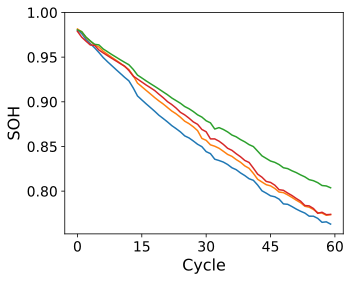

In [5]:
Battery_list = ['Cell1','Cell3','Cell7','Cell8' ]
data_root='../data/OXFORD_data/pinn_path/'
def smooth_data(sequence, window_size):
    """数据平滑"""
    if window_size < 1:
        raise ValueError("窗口大小必须大于等于1")
    # 初始化平滑后的数据列表
    smoothed_sequence = []
    # 计算窗口内的平均值
    for i in range(len(sequence)):
        # 计算窗口的起始和结束索引
        start_index = max(0, i - window_size + 1)
        end_index = i + 1
        # 计算窗口内的数据平均值
        window_average = sum(sequence[start_index:end_index]) / (end_index - start_index)
        # 将平均值添加到平滑后的数据列表中
        smoothed_sequence.append(window_average)
    return smoothed_sequence
def drop_outlier(array,count,bins):
    """离群值提取--用3sigma方法"""
    index = []
    range_n = np.arange(1,count,bins)
    for i in range_n[:-1]:
        array_lim = array[i:i+bins]
        sigma = np.std(array_lim)
        mean = np.mean(array_lim)
        th_max,th_min = mean + sigma*2, mean - sigma*2
        idx = np.where((array_lim < th_max) & (array_lim > th_min))
        idx = idx[0] + i
        index.extend(list(idx))
    return np.array(index)
def clean_data(array_figs,array_labels):
    index_keep=drop_outlier(array_labels,len(array_labels),35)
    array_figs,array_labels=array_figs[index_keep],array_labels[index_keep]
    array_figs,array_labels=array_figs[drop_outlier(array_labels,len(array_labels),10)],array_labels[drop_outlier(array_labels,len(array_labels),10)]
    return array_figs,array_labels
def add_row_index_to_array(arr):
    """
    在输入数组的每一行的第一个元素加上行号，并扩展数组维度。
    
    参数:
    arr (np.ndarray): 形状为 (n, 6) 的输入数组。
    
    返回:
    np.ndarray: 形状为 (n, 7) 的数组。
    """
    # 检查输入数组形状是否为 (n, 6)
    if arr.shape[1] != 6:
        raise ValueError("输入数组必须是形状为 (n, 6) 的数组。")

    # 创建一个新数组，其形状为 (n, 7)，初始化为输入数组
    new_arr = np.zeros((arr.shape[0], 7))
    new_arr[:, 1:] = arr  # 将输入数组的数据复制到新数组的后面六个列
    # 在新数组的每一行的第一个元素加上行号
    new_arr[:, 0] = np.arange(arr.shape[0])
    return new_arr
plt.figure(figsize=(5, 4))
df=pd.DataFrame()
for name in Battery_list:
    path=data_root+name+'.npz'
    arrays=np.load(path)
    features,SOHs=clean_data(arrays['array1'],arrays['array2'])
    df=add_column_with_variable_length(df,SOHs,name)
    plt.plot(SOHs)
    # """抛弃异常值处理"""
    # index_keep=drop_outlier(SOHs,len(SOHs),35)
    # plt.plot(SOHs[index_keep][drop_outlier(SOHs[index_keep],len(SOHs[index_keep]),10)])
    # plt.plot(process_sequence(SOHs,1))
    plt.yticks([0.8,0.85,0.9,0.95,1],fontsize=14)
    plt.xticks([0,15,30,45,60],fontsize=14)
    plt.xlabel('Cycle', fontsize=16)
    plt.ylabel('SOH',fontsize=16)
    print(features[1][0])
plt.show()
df.to_csv('../2origin/ox_soh.csv')

In [31]:
def setup_seed(seed):
    """set random seed"""
    np.random.seed(seed)  # Numpy module.
    random.seed(seed)  # Python random module.
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed) 
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

def evaluation(y_test, y_predict):
    mse = mean_squared_error(y_test, y_predict)
    rmse = sqrt(mean_squared_error(y_test, y_predict))
    return rmse
def get_data():
    """获取训练集，测试集，验证集"""
    train_list = Battery_list
    train_data=[]
    for b_n in train_list:
        path = '../data/OXFORD_data/pinn_path/' + b_n + '.npz'
        arrays = np.load(path)
        a,b=clean_data(arrays['array1'],arrays['array2'])
        a=add_row_index_to_array(a)
        train_data.append([a,b])
    train_valid_features=torch.from_numpy(np.concatenate((train_data[0][0],train_data[2][0]),axis=0)).float()
    train_valid_labels=torch.from_numpy(np.concatenate((train_data[0][1],train_data[2][1]),axis=0)).float()
    dataset=TensorDataset(train_valid_features,train_valid_labels)
    # 确定训练集和验证集的大小
    train_size = int(0.2 * len(dataset))  # 80%的训练集
    val_size = len(dataset) - train_size   # 剩余的20%作为验证集
    # 随机分割数据集
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    # 创建DataLoader
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
    test_7_data,test_8_data=[train_data[1][0],train_data[1][1]],[train_data[3][0],train_data[3][1]]
    return train_loader, val_loader, test_7_data,test_8_data

a,b,_,_,=get_data()
for x,y in b:
    print(x.shape)

torch.Size([16, 7])
torch.Size([16, 7])
torch.Size([16, 7])
torch.Size([16, 7])
torch.Size([16, 7])
torch.Size([16, 7])


In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, input_dim=11, output_dim=12, num_heads=4, head_dim=24, dropout=0):
        """用多头注意力进行解码"""
        """
        多头注意力模块。
        :param input_dim: 输入特征维度
        :param output_dim: 输出特征维度
        :param num_heads: 注意力头的数量
        :param head_dim: 每个注意力头的维度
        :param dropout: Dropout 概率
        """
        super(MultiHeadAttention, self).__init__()
        self.input_dim = input_dim-1
        self.output_dim = output_dim-1
        self.num_heads = num_heads
        self.head_dim = head_dim
        self.dropout = dropout
        # 线性变换层，将输入映射到 Q, K, V
        self.query = nn.Linear(input_dim-1, num_heads * head_dim)
        self.key = nn.Linear(input_dim-1, num_heads * head_dim)
        self.value = nn.Linear(input_dim-1, num_heads * head_dim)
        # 输出线性层
        self.fc_out = nn.Linear(num_heads * head_dim, output_dim-1)
        # Dropout 层
        self.dropout_layer = nn.Dropout(dropout)
    def forward(self, x):
        """
        前向传播。
        :param x: 输入张量，形状为 (batch_size, input_dim)
        :return: 输出张量，形状为 (batch_size, output_dim)
        """
        batch_size = x.size(0)
        x_t=x[:,0].unsqueeze(1)
        x=x[:,1:]
        # 线性变换，得到 Q, K, V
        Q = self.query(x).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)  # (batch_size, num_heads, seq_len, head_dim)
        K = self.key(x).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)    # (batch_size, num_heads, seq_len, head_dim)
        V = self.value(x).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)  # (batch_size, num_heads, seq_len, head_dim)
        # 计算注意力分数
        scores = torch.matmul(Q, K.transpose(-2, -1)) / torch.sqrt(torch.tensor(self.head_dim, dtype=torch.float32))  # (batch_size, num_heads, seq_len, seq_len)
        attention_weights = F.softmax(scores, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)
        attention_weights = self.dropout_layer(attention_weights)
        # 计算加权和
        attention_output = torch.matmul(attention_weights, V)  # (batch_size, num_heads, seq_len, head_dim)
        # 拼接多头输出
        attention_output = attention_output.transpose(1, 2).contiguous().view(batch_size, -1, self.num_heads * self.head_dim)  # (batch_size, seq_len, num_heads * head_dim)
        # 通过线性层映射到输出维度
        output = self.fc_out(attention_output)  # (batch_size, seq_len, output_dim)
        output=torch.cat((x_t,output.squeeze(1)),dim=-1)
        return output  # (batch_size, output_dim)
"""--------------------------------------------------------多物理场混合专家模型-------------------------------------------------------"""
class MixtureOfExperts(nn.Module):
    def __init__(self, input_dim, num_experts, expert_hidden_dim):
        super(MixtureOfExperts, self).__init__()
        self.num_experts = num_experts
        # 专家网络
        self.experts = nn.ModuleList([
            nn.Sequential(
                nn.Linear(input_dim, 2*expert_hidden_dim),
                nn.ReLU(),
                nn.Linear(2*expert_hidden_dim, 4*expert_hidden_dim),
                nn.ReLU(),
                nn.Linear(4*expert_hidden_dim, 8*expert_hidden_dim),
                nn.ReLU(),
                nn.Linear(8*expert_hidden_dim, 16*expert_hidden_dim),
                nn.ReLU(),
                nn.Linear(16*expert_hidden_dim, 32*expert_hidden_dim),
                nn.ReLU(),
                nn.Linear(32*expert_hidden_dim,64*expert_hidden_dim),
                nn.ReLU(),
                nn.Linear(64*expert_hidden_dim,32*expert_hidden_dim),
                nn.ReLU(),
                nn.Linear(32*expert_hidden_dim,16*expert_hidden_dim),
                nn.ReLU(),
                nn.Linear(16*expert_hidden_dim, 8*expert_hidden_dim),
                nn.ReLU(),
                nn.Linear(8*expert_hidden_dim, 4*expert_hidden_dim),
                nn.ReLU(),
                nn.Linear(4*expert_hidden_dim,expert_hidden_dim ),
            )
            for _ in range(num_experts)
        ])
        # 门控网络
        self.gating_network = nn.Linear(input_dim, num_experts)
        # 输出层
        self.output_layer = nn.Linear(expert_hidden_dim, 1)
    def initialize_weights(self):
        nn.init.xavier_uniform_(self.gating_network.weight)
        nn.init.xavier_uniform_(self.output_layer.weight)
    def forward(self, x):
        # 计算所有专家的输出
        expert_outputs = torch.stack([expert(x) for expert in self.experts], dim=1)
        #shape(batch_size,num_expert,expert_hidden_dim)
        # 计算门控网络的输出并应用softmax得到权重
        gate_works=torch.exp(self.gating_network(x)/500)
        gating_outputs = F.softmax(gate_works, dim=1)
        # 将门控网络的输出（权重）与专家网络的输出相乘并求和
        combined_output = torch.sum(expert_outputs * gating_outputs.unsqueeze(-1), dim=1)
        # 通过输出层得到最终输出
        final_output = self.output_layer(combined_output)
        return final_output,expert_outputs      #返回总输出和每个专家输出
    
class PINN_MOE(nn.Module):
    def __init__(self,input_dim=11, output_dim=12, num_heads=4, head_dim=24, dropout=0,expert_input_dim=12, num_experts=3,expert_hidden_dim=2):
        super(PINN_MOE, self).__init__()
        self.Decoupling=MultiHeadAttention(input_dim, output_dim, num_heads, head_dim, dropout)
        self.multi_physics=MixtureOfExperts(expert_input_dim, num_experts,expert_hidden_dim)
        self.physics=nn.Sequential(
            nn.Linear(6, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )
        # self.electricity=nn.Sequential(nn.Linear(expert_hidden_dim, 2*expert_hidden_dim),nn.ReLU(),nn.Linear(2*expert_hidden_dim,expert_hidden_dim),nn.ReLU(),nn.Linear(expert_hidden_dim,2))
        # self.heat=nn.Sequential(nn.Linear(expert_hidden_dim, 2*expert_hidden_dim),nn.ReLU(),nn.Linear(2*expert_hidden_dim,expert_hidden_dim),nn.ReLU(),nn.Linear(expert_hidden_dim,2))
        # self.mechine=nn.Sequential(nn.Linear(expert_hidden_dim, 2*expert_hidden_dim),nn.ReLU(),nn.Linear(2*expert_hidden_dim,expert_hidden_dim),nn.ReLU(),nn.Linear(expert_hidden_dim,2))
        self.parameter_heat=nn.Parameter(torch.tensor(1, dtype=torch.float32))
        self.parameter_electricity1=nn.Parameter(torch.tensor(1, dtype=torch.float32))
        self.parameter_electricity2=nn.Parameter(torch.tensor(1, dtype=torch.float32))
    def  initialize_weights(self):
        nn.init.xavier_uniform_(self.Decoupling.parameters)
        nn.init.xavier_uniform_(self.multi_physics.parameters)
        # nn.init.xavier_uniform_(self.heat.parameters)
        # nn.init.xavier_uniform_(self.mechine.parameters)
        # nn.init.xavier_uniform_(self.electricity.parameters)
        nn.init.xavier_uniform_(self.physics.parameters)
        nn.init.xavier_uniform_(self.parameter_heat)
        nn.init.xavier_uniform_(self.parameter_electricity1)
        nn.init.xavier_uniform_(self.parameter_electricity2)
    def forward(self, tx):
        tx.requires_grad_(True)
        # 解耦输入
        t_x = self.Decoupling(tx)
        def safe_grad(y, x_):
            # 如果 y 本身就不在计算图里（不需要梯度），直接返回 0（但要保持和 x_ 有依赖，方便二阶导）
            if (not torch.is_tensor(y)) or (not y.requires_grad):
                return x_ * 0.0

            g = grad(y, x_, create_graph=True, only_inputs=True, allow_unused=True)[0]
            if g is None:
                # 关键：不能用 zeros_like(x_)，要用 x_*0，让它仍然“挂在”x_上，从而有 grad_fn
                return x_ * 0.0
            return g

        t=t_x[:,0:1]
        x=t_x[:,1:]
        # 预测物理量
        s_pred,experts = self.multi_physics(torch.cat((t,x),dim=1))
        # 计算 s_pred 对 t 和 x 的偏导数
        """综合损失"""
        s_t = grad(s_pred.sum(),t,create_graph=True,only_inputs=True,allow_unused=True)[0]
        s_x = grad(s_pred.sum(),x,create_graph=True,only_inputs=True,allow_unused=True)[0]
        """热效应损失"""
        T_Q = experts[:, 0:1, :].squeeze(1)
        T = T_Q[:, 0:1]
        Q = T_Q[:, 1:2]

        # 选空间坐标（默认用 x 的第 1 维做空间坐标）
        x_phys = x[:, 0:1]

        # 梯度（用 safe_grad 防止 None）
        T_t  = safe_grad(T.sum(), t)
        T_x  = safe_grad(T.sum(), x_phys)
        T_xx = safe_grad(T_x.sum(), x_phys)

        rho_cp = 1.0
        k = self.parameter_heat

        res_heat = rho_cp * T_t - k * T_xx + Q

        loss_heat = torch.mean(res_heat ** 2, dim=1).unsqueeze(1)

        """电化学效应损失"""
        phi_c=experts[:,1:2,:].squeeze(1)
        phi=phi_c[:,0:1]
        c=phi_c[:,1:2]
        phi_t=grad(phi.sum(),t,create_graph=True,only_inputs=True,allow_unused=True)[0]
        phi_x=grad(phi.sum(),x,create_graph=True,only_inputs=True,allow_unused=True)[0]
        c_x=grad(c.sum(),x,create_graph=True,only_inputs=True,allow_unused=True)[0]
        c_t=grad(c.sum(),t,create_graph=True,only_inputs=True,allow_unused=True)[0]
        phi_laplace=grad(phi_x.sum(),x,create_graph=True,only_inputs=True,allow_unused=True)[0]
        c_laplace=grad(c_x.sum(),x,create_graph=True,only_inputs=True,allow_unused=True)[0]
        loss_electricity=torch.mean((c_t -self.parameter_electricity1 * c_laplace -self.parameter_electricity2) ** 2,dim=1).unsqueeze(1)+torch.mean(phi_laplace** 2,dim=1).unsqueeze(1)
        """机械应力损失"""
        sigma_f = experts[:, 2:3, :].squeeze(1)
        sigma = sigma_f[:, 0:1]
        f = sigma_f[:, 1:2]

        # 选空间坐标（默认用 x 的第 1 维做空间坐标）
        x_phys = x[:, 0:1]

        # 1D div(sigma) = dσ/dx
        sigma_x = safe_grad(sigma.sum(), x_phys)

        res_mech = sigma_x + f
        loss_mechine = torch.mean(res_mech ** 2, dim=1).unsqueeze(1)


        # 打印 s_t 和 s_x，确保它们不为 None
        # 计算物理约束 F
        F_input = torch.cat([phi,c,T,Q,sigma,f], dim=1)
        soh = self.physics(F_input)
        # 计算残差 f
        loss_all = 1*loss_electricity+1*loss_heat+1*loss_mechine
        return soh, loss_all,[phi,c,T,Q,sigma,f]


In [36]:
def train(lr=0.003,epochs=200, weight_decay=1e-4, seed=0, metric='rmse', device='cpu'):
    """function for train"""
    setup_seed(seed)
    print("training seed "+str(seed)+':\n')
    train_loader, val_loader, test_35_data, test_36_data=get_data()
    test_data=[test_35_data, test_36_data]
    model = PINN_MOE()
    model=model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    len_dataloader = len(train_loader)
    test_results=[]
    lists=[]
    """早停止获取最佳模型"""
    val_mse=10
    train_loss=10
    for epoch in range(epochs):
        loss_epoch=0
        for X,y in train_loader:
            X,y = X.to(device), y.to(device)
            y_pred,f,_= model(X)
            f_target = torch.zeros_like(f)
            y_pred = y_pred.squeeze(1)
            loss = criterion(y_pred,y)+0.3*criterion(f,f_target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_epoch += loss
        if (epoch+1)%5==0 and epoch!=0:
            print('Epoch:',epoch+1,'Train_RMSELoss:',loss_epoch/len_dataloader,'\n')
            train_loss=loss_epoch/len_dataloader
        if (epoch+1)%5==0 and epoch!=0:
            val_loss=0
            for val_x,val_y in val_loader:
                val_x,val_y=val_x.to(device),val_y.to(device)
                pre,_,_=model(val_x)
                val_loss+=criterion(pre.squeeze(1),val_y).detach()    
            print('Epoch:',epoch+1,'valid_RMSELoss:',val_loss/len(val_loader),'\n')
            val_mse=val_loss/len(val_loader)
                
        if (val_mse<1e-4 and train_loss<2e-4)or (epoch+1)==epochs:
            model=model.cpu()
            torch.save(model.state_dict(), '../pretrained/ox_model.pth')
            for name in test_data:
                X=torch.from_numpy(name[0]).float()
                y=name[1]
                y_pred,_,list=model(X)
                for i in range(len(list)):
                    list[i]=list[i].detach().cpu().numpy()
                lists.append(list)
                y_pred= y_pred.squeeze(0).detach().numpy()
                test_results.append([y,y_pred])
            break
    return test_results,lists
        

## 五个随机种子训练

In [37]:
tests=[]
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
for i in range(5):
    test_result,_=train(seed=i,device=device)
    tests.append(test_result)

training seed 0:

Epoch: 5 Train_RMSELoss: tensor(0.6768, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 5 valid_RMSELoss: tensor(0.6594, device='cuda:0') 

Epoch: 10 Train_RMSELoss: tensor(0.2927, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 10 valid_RMSELoss: tensor(0.1901, device='cuda:0') 

Epoch: 15 Train_RMSELoss: tensor(0.0264, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 15 valid_RMSELoss: tensor(0.0431, device='cuda:0') 

Epoch: 20 Train_RMSELoss: tensor(0.0149, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 20 valid_RMSELoss: tensor(0.0115, device='cuda:0') 

Epoch: 25 Train_RMSELoss: tensor(0.0098, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 25 valid_RMSELoss: tensor(0.0089, device='cuda:0') 

Epoch: 30 Train_RMSELoss: tensor(0.0050, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 30 valid_RMSELoss: tensor(0.0043, device='cuda:0') 

Epoch: 35 Train_RMSELoss: tensor(0.0036, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 35 valid_RMSELoss: tensor(0.0

In [38]:
def calculate_mae(actual, predicted):
    """
    计算两个序列的MAE（平均绝对误差）
    
    参数:
    actual (list or numpy array): 实际值序列
    predicted (list or numpy array): 预测值序列
    
    返回:
    float: MAE值
    """
    # 确保输入序列长度一致
    if len(actual) != len(predicted):
        raise ValueError("实际值序列和预测值序列长度必须一致")
    
    # 计算绝对误差
    absolute_errors = [abs(a - p) for a, p in zip(actual, predicted)]
    
    # 计算平均绝对误差
    mae = sum(absolute_errors) / len(actual)
    
    return mae
def mape(sequence_true, sequence_pred):
    """
    计算两个序列的MAPE（Mean Absolute Percentage Error）

    参数:
    sequence_true: 实际值序列
    sequence_pred: 预测值序列

    返回:
    mape: 平均绝对百分比误差
    """
    if len(sequence_true) != len(sequence_pred):
        raise ValueError("两个序列的长度必须相同")

    # 计算绝对百分比误差
    ape = [abs((true - pred) / true) for true, pred in zip(sequence_true, sequence_pred) if true != 0]

    # 计算平均绝对百分比误差
    mape = sum(ape) / len(ape)

    return mape

# 示例使用
sequence_true = [100, 200, 300, 400, 500]
sequence_pred = [90, 210, 310, 380, 480]
print("MAPE:", mape(sequence_true, sequence_pred))
def r_squared(y_true, y_pred):
    """
    计算两个序列的R方（R-squared）

    参数:
    y_true: 实际值序列
    y_pred: 预测值序列

    返回:
    r2: R方值
    """
    # 计算实际值的平均值
    y_mean = sum(y_true) / len(y_true)
    
    # 计算总平方和（Total Sum of Squares, TSS）
    ss_total = sum((y_true - y_mean) ** 2)
    
    # 计算回归平方和（Regression Sum of Squares, RSS）
    ss_residual = sum((y_true - y_pred) ** 2)
    
    # 计算R方
    r2 = 1 - (ss_residual / ss_total)
    
    return r2

MAPE: 0.05466666666666666


In [39]:
rmse_all=[]
mae_all=[]
mape_all=[]
r2=[]
num=0
test_csv_p=[]
real_csv_p=[]
for i in range(4):
    for j in range(len(tests[0])):
        real,pred=tests[i][j][0],tests[i][j][1].reshape(-1)
        rmse=evaluation(real,pred)
        if rmse>=0.00:
            rmse_all.append(rmse)
            for pre,rea in zip(pred,real):
                test_csv_p.append(pre)
                real_csv_p.append(rea)
        mae_all.append(calculate_mae(real,pred))
        mape_all.append(mape(real,pred))
        r2.append(r_squared(real,pred))
        num+=1
print("RMSE:",rmse_all)
print("test:",test_csv_p)
print('real:',real_csv_p)
len(test_csv_p)

RMSE: [0.009035501213406948, 0.009203396028787825, 0.011884223302984255, 0.010538888236915497, 0.0038347635417812507, 0.005108984410698255, 0.019858782420318084, 0.01739257866776374]
test: [0.9620776, 0.9620893, 0.96225613, 0.9624123, 0.96188647, 0.96027964, 0.9565991, 0.95277315, 0.94887537, 0.94487256, 0.9408409, 0.9368008, 0.9327764, 0.9287266, 0.92463714, 0.92060894, 0.9165837, 0.9125674, 0.90857, 0.90457696, 0.9005371, 0.8965587, 0.8925211, 0.88856477, 0.8845709, 0.8805106, 0.8765778, 0.87259907, 0.86853784, 0.8645172, 0.86055464, 0.8564843, 0.85245967, 0.8484803, 0.844546, 0.840756, 0.8370822, 0.83336943, 0.8297266, 0.8258897, 0.8221585, 0.8183448, 0.814575, 0.8108339, 0.80706435, 0.8041478, 0.8021347, 0.80099684, 0.80020636, 0.79998845, 0.79991025, 0.79986715, 0.7998282, 0.79978675, 0.7997536, 0.7997234, 0.79968786, 0.79965955, 0.79963714, 0.79961604, 0.96206087, 0.96208376, 0.9622396, 0.96239984, 0.9618735, 0.9602409, 0.9565419, 0.9527113, 0.94884914, 0.94479936, 0.94079965, 0.

480

## 测试

In [10]:
# rmse_all=0
# mae_all=0
# num=0
# for i in range(len(tests)):
#     for j in range(len(tests[0])):
#         real,pred=tests[i][j][0],tests[i][j][1]
#         rmse=evaluation(real,pred)
#         rmse_all+=(rmse)
#         mae_all+=calculate_mae(real,pred)
#         num+=1
# print('RMSE:',[rmse_all/num])
# print('MAE:',mae_all/num)

In [40]:
# device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# test_results,lists=train(seed=0,device=device)

In [20]:
reals=[]
preds=[]
for i in range(2):
    real,pred=test_results[i][0],test_results[i][1]
    reals.append(real)
    preds.append(pred)
reals=np.concatenate(reals,axis=0)
preds=np.concatenate(preds,axis=0).squeeze()
path='D:/Pywork/CNN_ATTENTION_PINN/new/results/preds/oxford.npz'
np.savez(path,reals=reals,preds=preds)

In [12]:
for i in range(2):
    real,pred=test_results[i][0],test_results[i][1]
    rmse=evaluation(real,pred)
    print(rmse)

0.003178889350747312
0.004840268991179267


In [43]:
class MLP(nn.Module):
    def __init__(self, input_size=7, output_size=1):
        super(MLP, self).__init__()
        self.net = nn.Sequential(nn.Linear(input_size, 32),
                                 nn.ReLU(),
                                 nn.Linear(32, 64),
                                 nn.ReLU(),
                                 nn.Linear(64, 128),
                                 nn.ReLU(),
                                 nn.Linear(128, 256),
                                 nn.Linear(256, 512),
                                 nn.ReLU(),
                                 nn.Linear(512, 128),
                                 nn.ReLU(),
                                 nn.Linear(128, 64),
                                 nn.ReLU(),
                                 nn.Linear(64, output_size))
    def forward(self, x):
        return self.net(x)
def train_mlp(lr=0.001,epochs=200, weight_decay=1e-4, seed=0, metric='rmse', device='cpu'):
    """function for train"""
    setup_seed(seed)
    print("training seed "+str(seed)+':\n')
    train_loader, val_loader, test_35_data, test_36_data=get_data()
    test_data=[test_35_data, test_36_data]
    model = MLP()
    model=model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    len_dataloader = len(train_loader)
    test_results=[]
    """早停止获取最佳模型"""
    val_mse=10
    for epoch in range(epochs):
        loss_epoch=0
        for X,y in train_loader:
            X,y = X.to(device), y.to(device)
            y_pred= model(X)
            y_pred = y_pred.squeeze(1)
            loss = criterion(y_pred,y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_epoch += loss
        if (epoch+1)%5==0 and epoch!=0:
            print('Epoch:',epoch+1,'Train_RMSELoss:',loss_epoch/len_dataloader,'\n')
        if (epoch+1)%5==0 and epoch!=0:
            val_loss=0
            for val_x,val_y in val_loader:
                val_x,val_y=val_x.to(device),val_y.to(device)
                pre=model(val_x)
                val_loss+=criterion(pre.squeeze(1),val_y).detach()    
            print('Epoch:',epoch+1,'valid_RMSELoss:',val_loss/len(val_loader),'\n')
            val_mse=val_loss/len(val_loader)
                
        if (val_mse<1e-3 and epoch>=35)or (epoch+1)==epochs:
            model=model.cpu()
            for name in test_data:
                X=torch.from_numpy(name[0]).float()
                y=name[1]
                y_pred=model(X)
                y_pred= y_pred.squeeze(0).detach().numpy()
                test_results.append([y,y_pred])
            break
    return test_results
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


In [44]:
tests_mlp=[]
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
for i in range(5):
    test_result=train_mlp(seed=i,device=device)
    tests_mlp.append(test_result)

training seed 0:

Epoch: 5 Train_RMSELoss: tensor(0.1899, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 5 valid_RMSELoss: tensor(0.2229, device='cuda:0') 

Epoch: 10 Train_RMSELoss: tensor(0.1088, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 10 valid_RMSELoss: tensor(0.1424, device='cuda:0') 

Epoch: 15 Train_RMSELoss: tensor(0.0758, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 15 valid_RMSELoss: tensor(0.0617, device='cuda:0') 

Epoch: 20 Train_RMSELoss: tensor(0.0039, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 20 valid_RMSELoss: tensor(0.0080, device='cuda:0') 

Epoch: 25 Train_RMSELoss: tensor(0.0036, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 25 valid_RMSELoss: tensor(0.0030, device='cuda:0') 

Epoch: 30 Train_RMSELoss: tensor(0.0018, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 30 valid_RMSELoss: tensor(0.0027, device='cuda:0') 

Epoch: 35 Train_RMSELoss: tensor(0.0012, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 35 valid_RMSELoss: tensor(0.0

In [45]:
rmse_all=[]
mae_all=[]
mape_all=[]
r2=[]
num=0
test_csv_m=[]
real_csv_m=[]
for i in range(4):
    for j in range(len(tests[0])):
        real,pred=tests_mlp[i][j][0],tests_mlp[i][j][1].reshape(-1)
        rmse=evaluation(real,pred)
        if rmse>=0.00:
            rmse_all.append(rmse)
            for pre,rea in zip(pred,real):
                test_csv_m.append(pre)
                real_csv_m.append(rea)
        mae_all.append(calculate_mae(real,pred))
        mape_all.append(mape(real,pred))
        r2.append(r_squared(real,pred))
        num+=1
print("RMSE:",rmse_all)
print("test:",test_csv_m)
print('real:',real_csv_m)
len(test_csv_m)

RMSE: [0.015028644268036833, 0.016278189828070704, 0.015725252489676884, 0.01612228968467474, 0.052856361685286235, 0.05595200003216431, 0.037785624352166064, 0.03758387782330728]
test: [0.9291835, 0.95185655, 0.9720506, 0.9725435, 0.9674511, 0.96341425, 0.95984614, 0.9539886, 0.945285, 0.9380253, 0.93213636, 0.92642885, 0.92029464, 0.9132666, 0.9035521, 0.8997174, 0.8964899, 0.8933232, 0.8919011, 0.88959056, 0.8843347, 0.88258886, 0.8775242, 0.8771587, 0.8747558, 0.86855555, 0.86943644, 0.86740416, 0.861079, 0.85685647, 0.85666126, 0.85127115, 0.84842557, 0.8482527, 0.8455587, 0.8413082, 0.8403632, 0.83664966, 0.8372312, 0.8305116, 0.83033305, 0.82492095, 0.8223739, 0.8215262, 0.8144943, 0.81631935, 0.81390846, 0.8083315, 0.81097966, 0.8097146, 0.80774575, 0.8068506, 0.8057174, 0.80222744, 0.8042924, 0.8057724, 0.8022147, 0.8050204, 0.80610543, 0.8034734, 0.92639476, 0.95099413, 0.96940345, 0.969689, 0.96546686, 0.96003723, 0.95549864, 0.95075434, 0.9421753, 0.9350762, 0.92995465, 0.9

480

In [27]:
# rmse_all=0
# mae_all=0
# num=0
# for i in range(len(tests_mlp)):
#     for j in range(len(tests_mlp[0])):
#         real,pred=tests_mlp[i][j][0],tests_mlp[i][j][1]
#         rmse=evaluation(real,pred)
#         rmse_all+=(rmse)
#         mae_all+=calculate_mae(real,pred)
#         num+=1
# print('RMSE:',[rmse_all/num])
# print('MAE:',mae_all/num)

RMSE: [0.02895238818411297]
MAE: [0.02083116]


## 挑出来一组画图

In [36]:
test_results_mlp=train_mlp(seed=1,device=device)

training seed 1:

Epoch: 5 Train_RMSELoss: tensor(0.0638, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 5 valid_RMSELoss: tensor(0.0575, device='cuda:0') 

Epoch: 10 Train_RMSELoss: tensor(0.0022, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 10 valid_RMSELoss: tensor(0.0020, device='cuda:0') 

Epoch: 15 Train_RMSELoss: tensor(0.0004, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 15 valid_RMSELoss: tensor(0.0007, device='cuda:0') 

Epoch: 20 Train_RMSELoss: tensor(0.0003, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 20 valid_RMSELoss: tensor(0.0002, device='cuda:0') 

Epoch: 25 Train_RMSELoss: tensor(0.0002, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 25 valid_RMSELoss: tensor(0.0002, device='cuda:0') 

Epoch: 30 Train_RMSELoss: tensor(0.0003, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 30 valid_RMSELoss: tensor(0.0002, device='cuda:0') 

Epoch: 35 Train_RMSELoss: tensor(0.0003, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 35 valid_RMSELoss: tensor(0.0

In [37]:
for i in range(2):
    real,pred=test_results_mlp[i][0],test_results_mlp[i][1]
    rmse=evaluation(real,pred)
    print(rmse)

0.01198461710176137
0.014795532963108166


In [47]:
class ConvNet(nn.Module):
    def __init__(self, n_input=7):
        super(ConvNet, self).__init__()
        # 输入重塑为 (batch, 1, n_input)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(32 * (n_input // 2), 64)  # 根据池化后的维度调整
        self.fc2 = nn.Sequential(nn.Linear(64 , 256),
                                 nn.ReLU(),
                                 nn.Linear(256, 64),
                                 nn.ReLU(),
                                 nn.Linear(64, 32),
                                 nn.ReLU(),
                                 nn.Linear(32, 1),)
    
    def forward(self, x):
        # 输入 x 的形状: (batch, n_input)
        x = x.unsqueeze(1)  # 重塑为 (batch, 1, n_input)
        x = self.conv1(x)   # 卷积后形状: (batch, 32, n_input)
        x = self.relu(x)
        x = self.pool(x)    # 池化后形状: (batch, 32, n_input // 2)
        x = x.view(x.size(0), -1)  # 展平为 (batch, 32 * (n_input // 2))
        x = self.fc1(x)     # 全连接层
        x = self.relu(x)
        x = self.fc2(x)     # 输出形状: (batch, 1)
        return x
def train_conv(lr=0.001,epochs=200, weight_decay=1e-4, seed=0, metric='rmse', device='cpu'):
    """function for train"""
    setup_seed(seed)
    print("training seed "+str(seed)+':\n')
    train_loader, val_loader, test_35_data, test_36_data=get_data()
    test_data=[test_35_data, test_36_data]
    model = ConvNet()
    model=model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    len_dataloader = len(train_loader)
    test_results=[]
    """早停止获取最佳模型"""
    val_mse=10
    for epoch in range(epochs):
        loss_epoch=0
        for X,y in train_loader:
            X,y = X.to(device), y.to(device)
            y_pred= model(X)
            y_pred = y_pred.squeeze(1)
            loss = criterion(y_pred,y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_epoch += loss
        if (epoch+1)%5==0 and epoch!=0:
            print('Epoch:',epoch+1,'Train_RMSELoss:',loss_epoch/len_dataloader,'\n')
        if (epoch+1)%5==0 and epoch!=0:
            val_loss=0
            for val_x,val_y in val_loader:
                val_x,val_y=val_x.to(device),val_y.to(device)
                pre=model(val_x)
                val_loss+=criterion(pre.squeeze(1),val_y).detach()    
            print('Epoch:',epoch+1,'valid_RMSELoss:',val_loss/len(val_loader),'\n')
            val_mse=val_loss/len(val_loader)
                
        if (val_mse<0.5e-4 and epoch>=35)or (epoch+1)==epochs:
            model=model.cpu()
            
            for name in test_data:
                X=torch.from_numpy(name[0]).float()
                y=name[1]
                y_pred=model(X)
                y_pred= y_pred.squeeze(0).detach().numpy()
                test_results.append([y,y_pred])
            break
    return test_results
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')



## 随机种子训练

In [48]:
tests_cnn=[]
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
for i in range(5):
    test_result=train_conv(seed=i,device=device)
    tests_cnn.append(test_result)

training seed 0:

Epoch: 5 Train_RMSELoss: tensor(0.2231, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 5 valid_RMSELoss: tensor(0.2034, device='cuda:0') 

Epoch: 10 Train_RMSELoss: tensor(0.1293, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 10 valid_RMSELoss: tensor(0.1216, device='cuda:0') 

Epoch: 15 Train_RMSELoss: tensor(0.0328, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 15 valid_RMSELoss: tensor(0.0239, device='cuda:0') 

Epoch: 20 Train_RMSELoss: tensor(0.0094, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 20 valid_RMSELoss: tensor(0.0094, device='cuda:0') 

Epoch: 25 Train_RMSELoss: tensor(0.0026, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 25 valid_RMSELoss: tensor(0.0048, device='cuda:0') 

Epoch: 30 Train_RMSELoss: tensor(0.0004, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 30 valid_RMSELoss: tensor(0.0005, device='cuda:0') 

Epoch: 35 Train_RMSELoss: tensor(0.0008, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 35 valid_RMSELoss: tensor(0.0

In [50]:
rmse_all=[]
mae_all=[]
mape_all=[]
r2=[]
num=0
test_csv_c=[]
real_csv_c=[]
for i in range(4):
    for j in range(len(tests[0])):
        real,pred=tests_cnn[i][j][0],tests_cnn[i][j][1].reshape(-1)
        rmse=evaluation(real,pred)
        if rmse>=0.00:
            rmse_all.append(rmse)
            for pre,rea in zip(pred,real):
                test_csv_c.append(pre)
                real_csv_c.append(rea)
        mae_all.append(calculate_mae(real,pred))
        mape_all.append(mape(real,pred))
        r2.append(r_squared(real,pred))
        num+=1
print("RMSE:",rmse_all)
print("test:",test_csv_c)
print('real:',real_csv_c)
len(test_csv_c)

RMSE: [0.011600442910434886, 0.01333707612980118, 0.010034469575548535, 0.01059629931538171, 0.00671935656190564, 0.00711514508611243, 0.03012614385218237, 0.030075749351074484]
test: [0.95095146, 0.9534142, 0.9666918, 0.9635536, 0.9600384, 0.9575727, 0.9514246, 0.95535034, 0.9521985, 0.94494194, 0.94317806, 0.9407112, 0.9334883, 0.92885816, 0.91703767, 0.91293293, 0.9119651, 0.90840274, 0.90507483, 0.90006775, 0.8893362, 0.8860781, 0.87770396, 0.87873, 0.8770786, 0.8679415, 0.87077534, 0.8654066, 0.85613924, 0.8492343, 0.8499926, 0.8418859, 0.8362718, 0.83706003, 0.8278874, 0.8213, 0.8210532, 0.81690395, 0.82043093, 0.8076516, 0.8093751, 0.799365, 0.796481, 0.79618967, 0.785898, 0.78883886, 0.78968066, 0.7824789, 0.78665286, 0.78452325, 0.78243804, 0.78067, 0.7780045, 0.7728108, 0.7725478, 0.77507097, 0.7685063, 0.7701455, 0.7731438, 0.7682804, 0.9444395, 0.951622, 0.96121895, 0.9576602, 0.95551497, 0.9503033, 0.94293773, 0.95041305, 0.9450012, 0.9419044, 0.93910116, 0.9370576, 0.9269

480

In [60]:
class LSTMNetwork(nn.Module):
    def __init__(self, input_size=7, hidden_size=60, num_layers=8, output_size=1):
        """
        LSTM网络初始化
        :param input_size: 输入特征的维度 (n)
        :param hidden_size: 隐藏层的维度
        :param num_layers: LSTM的层数
        :param output_size: 输出的维度 (1)
        """
        super(LSTMNetwork, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # 定义LSTM层
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        # 定义全连接层，将LSTM的输出映射到输出维度
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        """
        前向传播
        :param x: 输入数据，形状为 (batch_size, input_size)
        :return: 输出数据，形状为 (batch_size, output_size)
        """
        # 添加序列维度 (sequence_length=1)
        x = x.unsqueeze(1)  # 形状变为 (batch_size, 1, input_size)

        # 初始化隐藏状态和细胞状态
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # LSTM前向传播
        out, _ = self.lstm(x, (h0, c0))  # out的形状为 (batch_size, 1, hidden_size)

        # 只取最后一个时间步的输出
        out = out[:, -1, :]  # 形状为 (batch_size, hidden_size)

        # 全连接层映射到输出维度
        out = self.fc(out)  # 形状为 (batch_size, output_size)

        return out

def train_lstm(lr=0.001,epochs=150, weight_decay=1e-4, seed=0, metric='rmse', device='cpu'):
    """function for train"""
    """function for train"""
    setup_seed(seed)
    print("training seed "+str(seed)+':\n')
    train_loader, val_loader, test_35_data, test_36_data=get_data()
    test_data=[test_35_data, test_36_data]
    model = ConvNet()
    model=model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    len_dataloader = len(train_loader)
    test_results=[]
    """早停止获取最佳模型"""
    val_mse=10
    for epoch in range(epochs):
        loss_epoch=0
        for X,y in train_loader:
            X,y = X.to(device), y.to(device)
            y_pred= model(X)
            y_pred = y_pred.squeeze(1)
            loss = criterion(y_pred,y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_epoch += loss
        if (epoch+1)%5==0 and epoch!=0:
            print('Epoch:',epoch+1,'Train_RMSELoss:',loss_epoch/len_dataloader,'\n')
        if (epoch+1)%5==0 and epoch!=0:
            val_loss=0
            for val_x,val_y in val_loader:
                val_x,val_y=val_x.to(device),val_y.to(device)
                pre=model(val_x)
                val_loss+=criterion(pre.squeeze(1),val_y).detach()    
            print('Epoch:',epoch+1,'valid_RMSELoss:',val_loss/len(val_loader),'\n')
            val_mse=val_loss/len(val_loader)
                
        if (val_mse<0.5e-4 and epoch>=35)or (epoch+1)==epochs:
            model=model.cpu()
            
            for name in test_data:
                X=torch.from_numpy(name[0]).float()
                y=name[1]
                y_pred=model(X)
                y_pred= y_pred.squeeze(0).detach().numpy()
                test_results.append([y,y_pred])
            break
    return test_results
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [64]:
tests_lstm=[]
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
for i in range(5):
    test_result=train_lstm(seed=i,device=device)
    tests_lstm.append(test_result)

training seed 0:

Epoch: 5 Train_RMSELoss: tensor(0.2231, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 5 valid_RMSELoss: tensor(0.2034, device='cuda:0') 

Epoch: 10 Train_RMSELoss: tensor(0.1293, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 10 valid_RMSELoss: tensor(0.1216, device='cuda:0') 

Epoch: 15 Train_RMSELoss: tensor(0.0328, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 15 valid_RMSELoss: tensor(0.0239, device='cuda:0') 

Epoch: 20 Train_RMSELoss: tensor(0.0094, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 20 valid_RMSELoss: tensor(0.0094, device='cuda:0') 

Epoch: 25 Train_RMSELoss: tensor(0.0026, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 25 valid_RMSELoss: tensor(0.0048, device='cuda:0') 

Epoch: 30 Train_RMSELoss: tensor(0.0004, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 30 valid_RMSELoss: tensor(0.0005, device='cuda:0') 

Epoch: 35 Train_RMSELoss: tensor(0.0008, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 35 valid_RMSELoss: tensor(0.0

In [65]:
rmse_all=[]
mae_all=[]
mape_all=[]
r2=[]
num=0
test_csv_l=[]
real_csv_l=[]
for i in range(4):
    for j in range(len(tests_lstm[0])):
        real,pred=tests_lstm[i][j][0],tests_lstm[i][j][1].reshape(-1)
        rmse=evaluation(real,pred)
        if rmse>=0.0:
            rmse_all.append(rmse)
            for pre,rea in zip(pred,real):
                test_csv_l.append(pre)
                real_csv_l.append(rea)
        mae_all.append(calculate_mae(real,pred))
        mape_all.append(mape(real,pred))
        r2.append(r_squared(real,pred))
        num+=1
print("RMSE:",rmse_all)
print("test:",test_csv_l)
print('real:',real_csv_l)
len(test_csv_l)

RMSE: [0.011139777170736768, 0.00943706538333564, 0.009190314113245173, 0.00859194635363915, 0.006808533028591805, 0.007392834235689803, 0.025182748267340627, 0.02528002333529779]
test: [0.96285355, 0.96507096, 0.9799489, 0.97558045, 0.9732497, 0.9709543, 0.96489346, 0.9690279, 0.9659172, 0.9587381, 0.957013, 0.9541936, 0.9473741, 0.9427943, 0.9311254, 0.9273033, 0.92681706, 0.9238987, 0.9208176, 0.9154465, 0.9049188, 0.9019022, 0.89380157, 0.8950963, 0.8937149, 0.88482, 0.8879218, 0.88277674, 0.87375724, 0.86705685, 0.8679931, 0.8595048, 0.85411704, 0.85515356, 0.8461671, 0.8398782, 0.8397573, 0.8359028, 0.83971953, 0.82720697, 0.8292171, 0.81947505, 0.81687725, 0.8169235, 0.80739784, 0.8105538, 0.8111073, 0.8033253, 0.8077272, 0.80587435, 0.8040832, 0.8026023, 0.80022407, 0.795323, 0.79533446, 0.79814684, 0.7918786, 0.79378116, 0.7970772, 0.7925036, 0.95625114, 0.9632498, 0.97429895, 0.96957386, 0.9686761, 0.96360207, 0.9563066, 0.964051, 0.9586408, 0.9556184, 0.9528589, 0.9505725, 0

480

In [66]:
import pandas as pd
data={
    'prop pred':test_csv_p,
    'prop real':real_csv_p,
    'mlp pred': test_csv_m,
    'mlp real':real_csv_m,
    'cnn pred': test_csv_c,
    'cnn real':real_csv_c,
    'lstm pred':test_csv_l,
    'lstm real':real_csv_l,
}
df=pd.DataFrame(data)
print(df)
df.to_csv('../csv_results/oxford.csv',index=False)

     prop pred  prop real  mlp pred  mlp real  cnn pred  cnn real  lstm pred  \
0     0.962078   0.981548  0.929183  0.981548  0.950951  0.981548   0.962854   
1     0.962089   0.978319  0.951857  0.978319  0.953414  0.978319   0.965071   
2     0.962256   0.972058  0.972051  0.972058  0.966692  0.972058   0.979949   
3     0.962412   0.967740  0.972543  0.967740  0.963554  0.967740   0.975580   
4     0.961886   0.963712  0.967451  0.963712  0.960038  0.963712   0.973250   
..         ...        ...       ...       ...       ...       ...        ...   
475   0.815731   0.780606  0.796938  0.780606  0.815650  0.780606   0.801483   
476   0.814962   0.775192  0.790979  0.775192  0.807724  0.775192   0.793913   
477   0.814319   0.776401  0.797688  0.776401  0.813687  0.776401   0.800388   
478   0.813737   0.773682  0.802601  0.773682  0.819984  0.773682   0.807259   
479   0.813217   0.773972  0.795328  0.773972  0.811265  0.773972   0.799484   

     lstm real  
0     0.981548  
1    

In [22]:
rmse_all=0
mae_all=0
num=0
for i in range(len(tests_cnn)):
    for j in range(len(tests_cnn[0])):
        real,pred=tests_cnn[i][j][0],tests_cnn[i][j][1]
        rmse=evaluation(real,pred)
        rmse_all+=(rmse)
        mae_all+=calculate_mae(real,pred)
        num+=1
print('RMSE:',[rmse_all/num])
print('MAE:',mae_all/num)

RMSE: [0.014090784054268298]
MAE: [0.01106635]


## 取出一组画图

In [42]:
test_results_conv=train_conv(seed=0,device=device)

training seed 0:

Epoch: 5 Train_RMSELoss: tensor(0.0477, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 5 valid_RMSELoss: tensor(0.0166, device='cuda:0') 

Epoch: 10 Train_RMSELoss: tensor(0.0014, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 10 valid_RMSELoss: tensor(0.0004, device='cuda:0') 

Epoch: 15 Train_RMSELoss: tensor(0.0002, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 15 valid_RMSELoss: tensor(0.0001, device='cuda:0') 

Epoch: 20 Train_RMSELoss: tensor(0.0004, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 20 valid_RMSELoss: tensor(0.0005, device='cuda:0') 

Epoch: 25 Train_RMSELoss: tensor(0.0011, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 25 valid_RMSELoss: tensor(0.0015, device='cuda:0') 

Epoch: 30 Train_RMSELoss: tensor(0.0004, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 30 valid_RMSELoss: tensor(0.0001, device='cuda:0') 

Epoch: 35 Train_RMSELoss: tensor(0.0002, device='cuda:0', grad_fn=<DivBackward0>) 

Epoch: 35 valid_RMSELoss: tensor(0.0

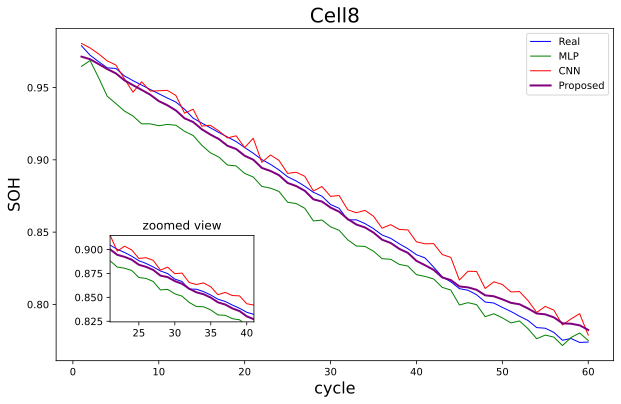

In [47]:
def plot_curves_with_zoom( y_real, y_mlp, y_cnn ,y_proposed,zoom='zoomed view',title='CS2_35 Battery'):
    # 创建主图
    plt.figure(figsize=(10, 6))

    x_real = np.arange(1, len(y_real) + 1)
    # 绘制主图中的四条曲线
    plt.plot(x_real, y_real, label='Real', color='blue', linewidth=1)
    plt.plot(x_real, y_mlp, label='MLP', color='green', linewidth=1)
    plt.plot(x_real, y_cnn, label='CNN', color='red', linewidth=1)
    plt.plot(x_real, y_proposed, label='Proposed', color='purple', linewidth=2)
    
    # 设置主图标题和标签
    plt.title(title,fontsize=20)
    plt.xlabel('cycle',fontsize=16)
    plt.ylabel('SOH',fontsize=16)
    plt.legend(loc='upper right')  # 图例在右上角
    
    # 添加放大图
    ax_inset = plt.axes([0.2, 0.2, 0.2, 0.2])  # 放大图的位置和大小
    ax_inset.plot(x_real, y_real, color='blue', linewidth=1)
    ax_inset.plot(x_real, y_mlp, color='green', linewidth=1)
    ax_inset.plot(x_real, y_cnn, color='red', linewidth=1)
    ax_inset.plot(x_real, y_proposed, color='purple', linewidth=2)
    
    # 设置放大图的显示范围（取中间一小段）
    mid_point = len(x_real) // 2
    zoom_range = 10  # 放大范围
    ax_inset.set_xlim(x_real[mid_point - zoom_range], x_real[mid_point + zoom_range])
    ax_inset.set_ylim(min(y_real[mid_point - zoom_range:mid_point + zoom_range]) - 0.01,
                      max(y_real[mid_point - zoom_range:mid_point + zoom_range]) + 0.01)
    
    # 设置放大图标题
    ax_inset.set_title(zoom)
    
    # 显示图像
    plt.show()

# 示例数据
x = np.linspace(0, 10, 500)
y_real = np.sin(x)
y_mlp = np.sin(x) + 0.1 * np.random.normal(size=len(x))
y_cnn = np.sin(x) + 0.05 * np.random.normal(size=len(x))
y_proposed = np.sin(x) + 0.02 * np.random.normal(size=len(x))

# 调用函数
plot_curves_with_zoom(test_results[1][0],test_results_mlp[1][1], 
                      test_results_conv[1][1],test_results[1][1],title='Cell8')

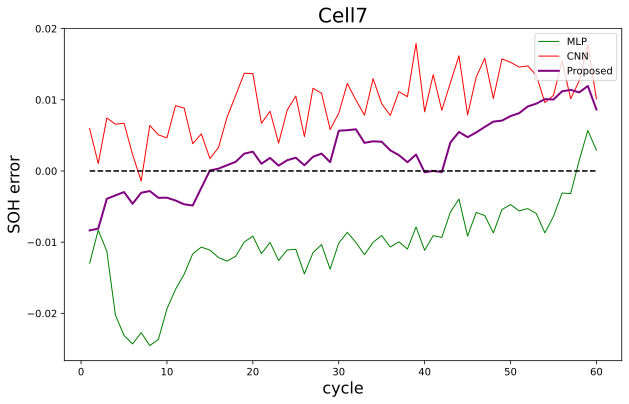

In [51]:
def subtract_lists(list1, list2):
    if len(list1) != len(list2):
        raise ValueError("两个列表的长度必须相同！")
    return [x - y for x, y in zip(list1, list2)]
def plot_difference_curves(y_real, y_mlp, y_cnn, y_proposed,title='C2S'):
    # 生成 x 值（从 1 开始递增）
    # 创建主图
    plt.figure(figsize=(10, 6))

    x_real = np.arange(1, len(y_real) + 1)
    # 绘制主图中的四条曲线
    plt.plot(x_real, y_mlp-y_real, label='MLP', color='green', linewidth=1)
    plt.plot(x_real, y_cnn-y_real, label='CNN', color='red', linewidth=1)
    
    plt.plot(x_real, y_proposed-y_real, label='Proposed', color='purple', linewidth=2)
    plt.plot(x_real,0*y_mlp,color='black',linestyle='--')
    # 设置主图标题和标签
    plt.title(title,fontsize=20)
    plt.xlabel('cycle',fontsize=16)
    plt.ylabel('SOH error',fontsize=16)
    plt.legend(loc='upper right')  # 图例在右上角
    plt.show()
plot_difference_curves(test_results[0][0],test_results_mlp[0][1].reshape(-1), 
                       test_results_conv[0][1].reshape(-1),
                       test_results[0][1].reshape(-1),title='Cell7')